In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [65]:
# Input data
mar_arc = [
    0.283, 0.214, 0.204, 0.216, 0.205, 0.163, 0.177, 0.185, 0.174, 0.178,
    0.172, 0.174, 0.172, 0.184, 0.192, 0.178, 0.178, 0.177, 0.181, 0.171,
    0.187, 0.177, 0.190, 0.199, 0.191, 0.181, 0.192, 0.192, 0.193, 0.207
]

mar_glo = [
    0.026, 0.028, 0.026, 0.026, 0.027
]

apr_arc = [
    0.232, 0.171, 0.151, 0.156, 0.152, 0.150, 0.142, 0.147, 0.143, 0.137,
    0.135, 0.132, 0.135, 0.144, 0.138, 0.134, 0.145, 0.144, 0.142, 0.154,
    0.146, 0.155, 0.145, 0.142, 0.144, 0.140, 0.141, 0.145, 0.150, 0.158
]

apr_glo = [
    0.025, 0.025, 0.025, 0.024, 0.025
]

may_arc = [
    0.167, 0.100, 0.098, 0.092, 0.099, 0.093, 0.092, 0.089, 0.087, 0.089,
    0.088, 0.089, 0.083, 0.096, 0.091, 0.086, 0.087, 0.079, 0.076, 0.079,
    0.084, 0.084, 0.081, 0.086, 0.080, 0.081, 0.080, 0.082, 0.080, 0.081
]

may_glo = [
    0.023, 0.021, 0.023, 0.022, 0.022
]

In [67]:
# Save data
month = "april"
region = "arctic"

arr_dict = {
    'march': mar_arc,
    'april': apr_arc,
    'may': may_arc
}
arr = arr_dict.get(month.lower())

if arr is None:
    raise ValueError(f"No RMSE data found for month '{month}' and region '{region}'")

# Define x variable
n_comps = range(1, 31)

# Create a DataArray
data = xr.DataArray(
    data=arr,
    coords={"n_comps": n_comps},
    dims=["n_comps"],
)

# Add attributes
data.attrs["units"] = "K/decade"

# Save to NetCDF
data.to_netcdf(f"./rmse_vals/{month}_{region}_intRMSE_.nc", engine='netcdf4')
print(f"NetCDF file '{month}_{region}_intRMSE_.nc' created.")

NetCDF file 'march_arctic_intRMSE_.nc' created.


0.15


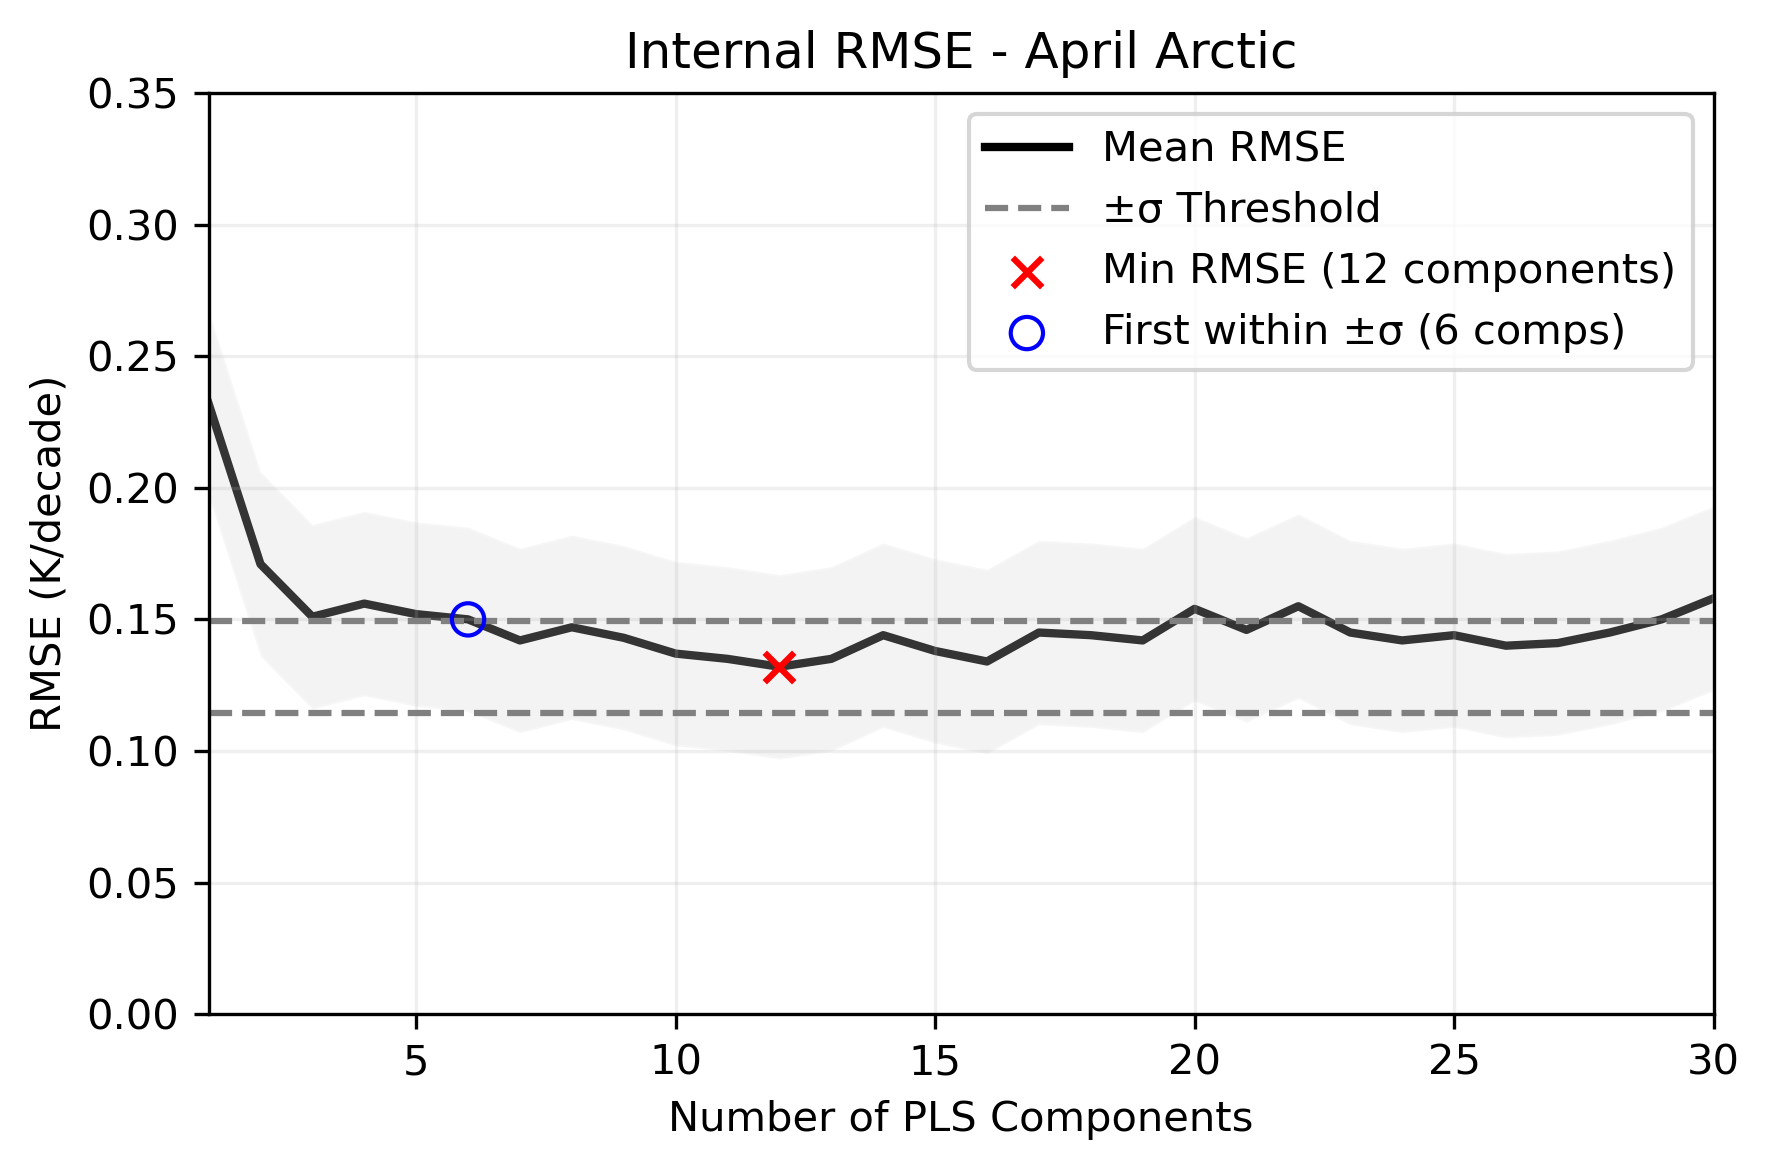

In [72]:
# Open the NetCDF file
month = 'april'
region = 'arctic'
ds = xr.open_dataset(f'./rmse_vals/{month}_{region}_intRMSE.nc')

# Get x and y values
x = ds["n_comps"].values
y = ds.__xarray_dataarray_variable__.values

# Min RMSE and standard deviation
min_idx = np.argmin(y)
min_y = y[min_idx]
std = np.std(y)

# Thresholds
lower_thresh = min_y - std
upper_thresh = min_y + std
eps = 0.001

# Find first index within the ±1σ threshold
within_thresh_idx = np.where((y >= lower_thresh-eps) & (y <= upper_thresh+eps))[0]
first_within_idx = within_thresh_idx[0] if len(within_thresh_idx) > 0 else None

# Plot
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(x, y, color='k', label='Mean RMSE', lw=2, zorder=0)

# Shaded region for ±2σ
plt.fill_between(x, y-2*std, y+2*std, color='lightgrey', edgecolor='white', alpha=0.25)

# Horizontal lines for ±σ
plt.axhline(y=min_y-std, ls='--', color='grey', label='±σ Threshold')
plt.axhline(y=min_y+std, ls='--', color='grey')

# Minimum RMSE marker
plt.scatter(min_idx+1, min_y,
            marker='x', s=50, color='red',
            label=f'Min RMSE ({min_idx+1} components)',
            zorder=1)

# First point within threshold marker
if first_within_idx is not None:
    plt.scatter(x[first_within_idx], y[first_within_idx],
                marker='o', s=60, facecolors='none', edgecolors='blue',
                label=f'First within ±σ ({x[first_within_idx]} comps)',
                zorder=2)
    print(y[first_within_idx])

# Formatting
plt.title(f"Internal RMSE - {month.capitalize()} {region.capitalize()}")
plt.xlabel("Number of PLS Components")
plt.ylabel("RMSE (K/decade)")
plt.tight_layout()
plt.legend(loc='upper right')
plt.xlim(1, 30)
plt.ylim(0, 0.35)
plt.grid(alpha=0.2)

# Show plot
# plt.savefig(f'./rmse_vals/{month}_{region}_rmse_plot.png', dpi=300)
plt.show()